## Build Dataset

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import (accuracy_score, classification_report, roc_auc_score, mean_squared_error, r2_score, confusion_matrix ,ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler

In [18]:
np.random.seed(42)
n = 1000

In [19]:
df = pd.DataFrame({
    'study_hours'   : np.random.normal(6, 2, n).clip(0, 12),
    'sleep_hours'   : np.random.normal(7, 1.5, n).clip(3, 10),
    'attendance_pct': np.random.normal(75, 15, n).clip(0, 100),
    'prev_score'    : np.random.normal(65, 15, n).clip(0, 100),
    'stress_level'  : np.random.randint(1, 10, n).astype(float),
    'exercise_days' : np.random.randint(0, 7, n).astype(float)})

In [20]:
score = (
    df['study_hours']    * 4.0 +
    df['attendance_pct'] * 0.3 +
    df['prev_score']     * 0.4 +
    df['sleep_hours']    * 1.5 +
    np.random.normal(0, 5, n))

In [21]:
df['result']       = (score > score.median()).astype(int)
df['actual_score'] = score

In [22]:
df.head()

,study_hours,sleep_hours,attendance_pct,prev_score,stress_level,exercise_days,result,actual_score
0,6.993428,9.099033,64.872326,36.382887,8.0,5.0,0,75.015686
1,5.723471,8.386951,72.832220,52.094225,3.0,1.0,0,77.104746
2,7.295377,7.089446,63.113701,58.795917,8.0,1.0,1,86.001211
3,9.046060,6.029595,70.380577,93.315315,8.0,0.0,1,105.296819
4,5.531693,8.047335,46.595780,73.348297,5.0,5.0,1,88.894955


In [23]:
feature_names = list(df.columns[:6])
feature_names

['study_hours',
 'sleep_hours',
 'attendance_pct',
 'prev_score',
 'stress_level',
 'exercise_days']

In [24]:
X = df[feature_names]
y_clf = df['result']
y_reg = df['actual_score']

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y_clf, test_size=0.2, stratify=y_clf, random_state=42)

In [26]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X, y_reg, test_size=0.2, random_state=42)

# Classification

In [27]:
xgb_clf = xgb.XGBClassifier(

    n_estimators      = 100,
    # ↑ number of boosting rounds
    #   more = better until overfitting

    learning_rate     = 0.1,
    # ↑ eta — shrinks each tree contribution
    #   lower = more conservative, needs more trees
    #   typical: 0.01 to 0.3

    max_depth         = 6,
    # ↑ maximum depth of each tree
    #   deeper = more complex = more overfit risk
    #   typical: 3 to 10

    min_child_weight  = 1,
    # ↑ minimum sum of hessians in a leaf
    #   higher = more conservative (fewer splits)
    #   controls minimum data in each leaf
    #   like min_samples_leaf but uses hessian sum

    gamma             = 0,
    # ↑ minimum loss reduction to make a split
    #   higher = more conservative (fewer splits)
    #   0 = split whenever any improvement exists

    subsample         = 0.8,
    # ↑ fraction of samples per tree
    #   <1.0 = stochastic boosting
    #   reduces overfitting, adds randomness

    colsample_bytree  = 0.8,
    # ↑ fraction of features per tree
    #   like Random Forest's max_features
    #   reduces correlation between trees

    colsample_bylevel = 1.0,
    # ↑ fraction of features per depth level

    colsample_bynode  = 1.0,
    # ↑ fraction of features per split node

    reg_alpha         = 0,
    # ↑ L1 regularization on leaf weights
    #   higher = sparser model (some leaves → 0)

    reg_lambda        = 1,
    # ↑ L2 regularization on leaf weights
    #   higher = smaller leaf weights
    #   default=1, always helps a bit

    scale_pos_weight  = 1,
    # ↑ for imbalanced data
    #   set to: count(negative) / count(positive)
    #   e.g. 950/50 = 19 for fraud detection

    eval_metric       = 'logloss',
    # ↑ metric to monitor during training
    #   classification: 'logloss', 'error', 'auc'
    #   regression: 'rmse', 'mae'

    use_label_encoder = False,
    random_state      = 42,
    n_jobs            = -1)

In [29]:
xgb_clf

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,1.0
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,1.0
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

In [30]:
xgb_clf.fit(
    X_train, y_train,
    eval_set = [(X_train, y_train), (X_test,  y_test)],
    # ↑ monitor performance on both sets during training
    verbose = False)


D:\Complete ML\Data Science\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [04:33:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,1.0
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,1.0
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

In [31]:
y_pred = xgb_clf.predict(X_test)
y_prob = xgb_clf.predict_proba(X_test)[:, 1]

print("XGBoost Classification:")
print(f"  Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")
print(classification_report(y_test, y_pred,
      target_names=['Fail', 'Pass']))

XGBoost Classification:
  Accuracy : 0.8400
  ROC-AUC  : 0.9238
              precision    recall  f1-score   support

        Fail       0.85      0.82      0.84       100
        Pass       0.83      0.86      0.84       100

    accuracy                           0.84       200
   macro avg       0.84      0.84      0.84       200
weighted avg       0.84      0.84      0.84       200



In [33]:
y_prob

array([0.93648964, 0.08072988, 0.00171626, 0.005584  , 0.32125005,
       0.9904732 , 0.9865145 , 0.94343764, 0.39884633, 0.0079176 ,
       0.9981775 , 0.49839708, 0.99672323, 0.02589727, 0.00628408,
       0.39601678, 0.22888719, 0.07759221, 0.19991295, 0.0767049 ,
       0.652005  , 0.02487884, 0.42540655, 0.02603719, 0.95367825,
       0.99268556, 0.9561121 , 0.9972109 , 0.03765958, 0.9566768 ,
       0.00528604, 0.99723405, 0.99585956, 0.9955048 , 0.9880283 ,
       0.088114  , 0.09823099, 0.1575374 , 0.02614357, 0.813678  ,
       0.9225013 , 0.6424727 , 0.75740725, 0.04818271, 0.01346364,
       0.620272  , 0.01268372, 0.99410534, 0.8687435 , 0.00296973,
       0.9952301 , 0.00483458, 0.9766615 , 0.46378064, 0.98730135,
       0.08439158, 0.8157079 , 0.00721111, 0.7714209 , 0.8767087 ,
       0.9244681 , 0.11551367, 0.9967828 , 0.12222308, 0.17243147,
       0.26341072, 0.99105835, 0.9730128 , 0.01269338, 0.02147145,
       0.06853565, 0.01059528, 0.99040097, 0.9778356 , 0.97348

# Plot training Curves

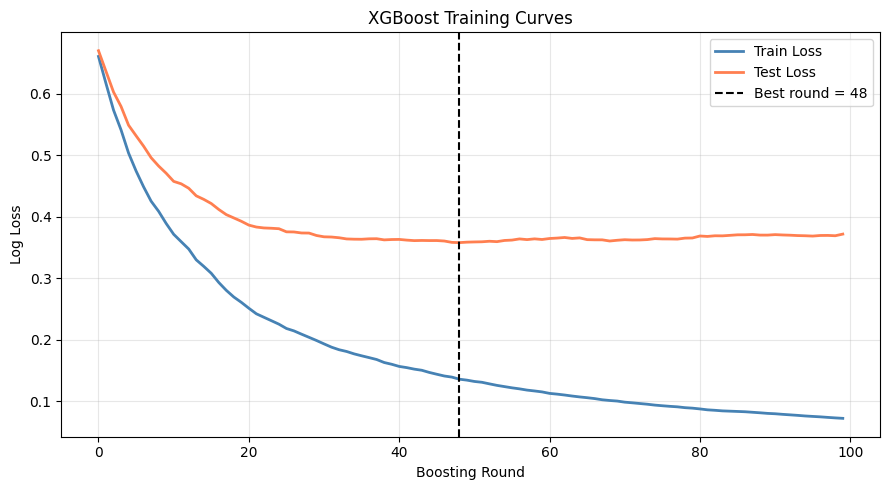

Best round        : 48
Best test logloss : 0.3579


In [34]:
# Access training history
results = xgb_clf.evals_result()
# ↑ dictionary with train and test metrics per round

train_loss = results['validation_0']['logloss']
test_loss  = results['validation_1']['logloss']

plt.figure(figsize=(9, 5))
plt.plot(train_loss, color='steelblue',
         linewidth=2, label='Train Loss')
plt.plot(test_loss,  color='coral',
         linewidth=2, label='Test Loss')

# Find optimal rounds
best_round = np.argmin(test_loss)
plt.axvline(x=best_round, color='black',
            linestyle='--',
            label=f'Best round = {best_round}')

plt.xlabel("Boosting Round")
plt.ylabel("Log Loss")
plt.title("XGBoost Training Curves")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best round        : {best_round}")
print(f"Best test logloss : {test_loss[best_round]:.4f}")

# Early Stopping

In [41]:
xgb_early = xgb.XGBClassifier(
    n_estimators          = 1000,
    learning_rate         = 0.1,
    max_depth             = 6,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    early_stopping_rounds = 20,    # ← in constructor
    eval_metric           = 'logloss',
    random_state          = 42,
    n_jobs                = -1
    # ↑ use_label_encoder removed in XGBoost >= 1.7
    #   no need to pass it at all
)

xgb_early.fit(
    X_train, y_train,
    eval_set = [(X_test, y_test)],
    verbose  = False
)

print(f"Best iteration : {xgb_early.best_iteration}")
print(f"Best score     : {xgb_early.best_score:.4f}")
print(f"Test AUC       : {roc_auc_score(y_test, xgb_early.predict_proba(X_test)[:, 1]):.4f}")

Best iteration : 48
Best score     : 0.3579
Test AUC       : 0.9234


# Feature Importance

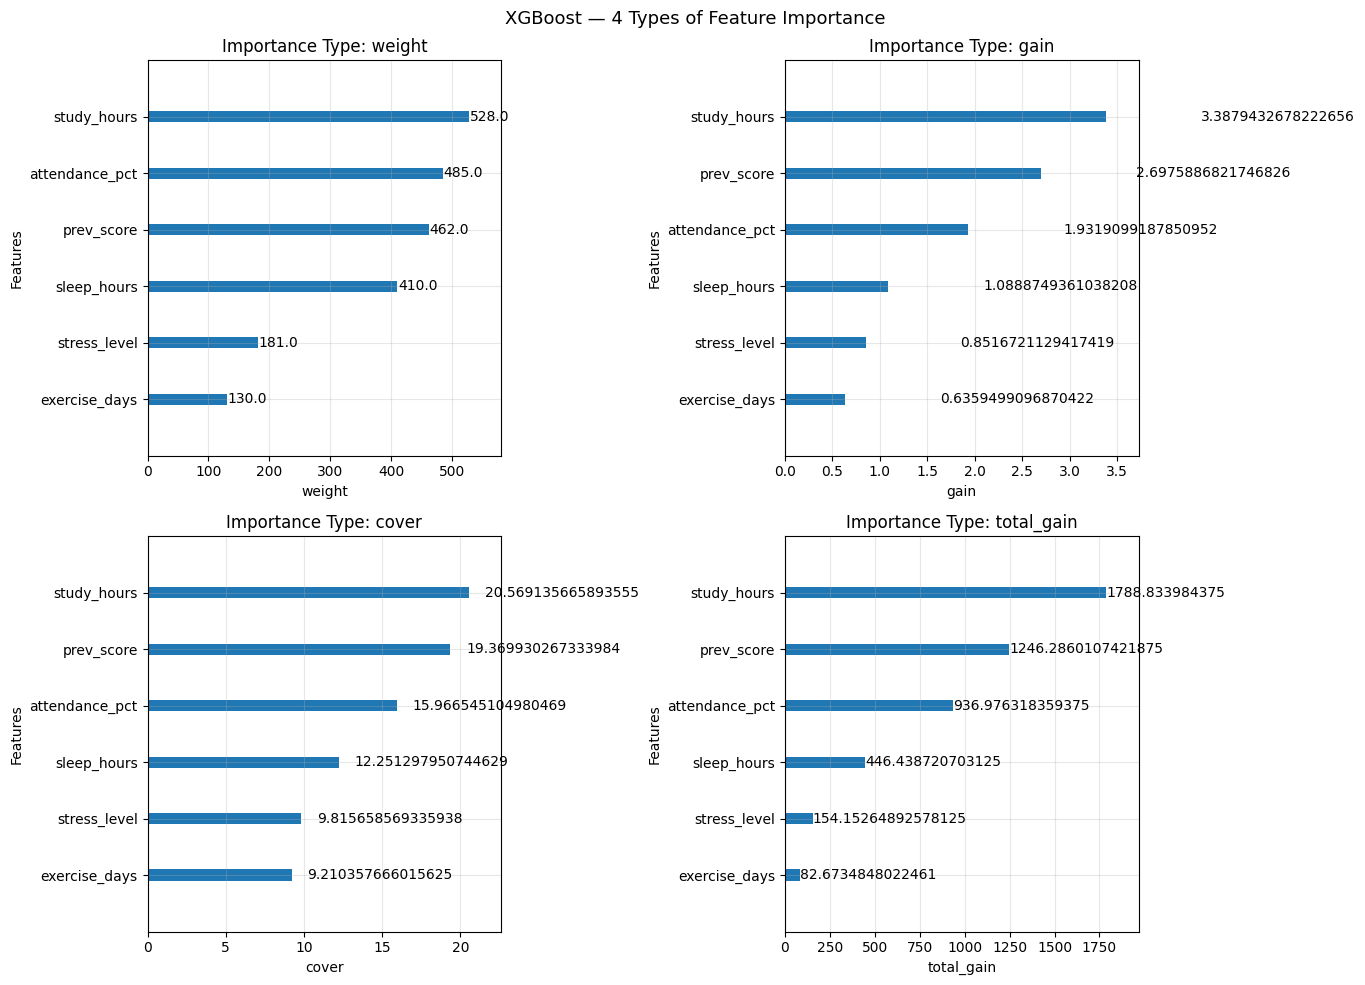

In [36]:
# XGBoost has 4 types of feature importance

importance_types = ['weight', 'gain', 'cover', 'total_gain']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, imp_type in zip(axes, importance_types):
    xgb.plot_importance(
        xgb_clf,
        ax             = ax,
        importance_type= imp_type,
        # weight     : how many times feature used in splits
        # gain       : average loss reduction per split
        # cover      : average number of samples per split
        # total_gain : total gain across all splits
        title          = f'Importance Type: {imp_type}',
        xlabel         = imp_type,
        show_values    = True
    )
    ax.grid(True, alpha=0.3)

plt.suptitle("XGBoost — 4 Types of Feature Importance",
             fontsize=13)
plt.tight_layout()
plt.show()

# gain = most meaningful importance type
# weight can be misleading (high cardinality features used more)
# total_gain = gain × weight = good overall measure

# Regression

In [37]:
xgb_reg = xgb.XGBRegressor(
    n_estimators     = 100,
    learning_rate    = 0.1,
    max_depth        = 6,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    reg_alpha        = 0,
    reg_lambda       = 1,
    eval_metric      = 'rmse',
    random_state     = 42,
    n_jobs           = -1
)

xgb_reg.fit(
    X_train_r, y_train_r,
    eval_set = [(X_test_r, y_test_r)],
    verbose  = False
)

y_pred_r = xgb_reg.predict(X_test_r)

print("XGBoost Regression:")
print(f"  R² Score : {r2_score(y_test_r, y_pred_r):.4f}")
print(f"  RMSE     : {mean_squared_error(y_test_r, y_pred_r)**0.5:.4f}")

XGBoost Regression:
  R² Score : 0.7504
  RMSE     : 6.2864


# Hyperparameter Tuning

In [39]:
param_grid = {
    'n_estimators'     : [100, 200, 300],
    'learning_rate'    : [0.01, 0.05, 0.1, 0.2],
    'max_depth'        : [3, 4, 6, 8],
    'min_child_weight' : [1, 3, 5],
    'subsample'        : [0.7, 0.8, 1.0],
    'colsample_bytree' : [0.7, 0.8, 1.0],
    'gamma'            : [0, 0.1, 0.5],
    'reg_alpha'        : [0, 0.1, 1.0],
    'reg_lambda'       : [1, 1.5, 2.0],
}

# Use RandomizedSearchCV (too many combinations for Grid)
random_search = RandomizedSearchCV(
    xgb.XGBClassifier(
        eval_metric  = 'logloss',
        random_state = 42,
        n_jobs       = -1
    ),
    param_distributions = param_grid,
    n_iter              = 50,
    cv                  = 5,
    scoring             = 'roc_auc',
    random_state        = 42,
    n_jobs              = -1,
    verbose             = 1
)

random_search.fit(X_train, y_train)
print("\nBest Parameters:", random_search.best_params_)
print("Best CV AUC    :", random_search.best_score_.round(4))
print("Test AUC       :",
      roc_auc_score(y_test,
      random_search.predict_proba(X_test)[:,1]))

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best Parameters: {'subsample': 0.7, 'reg_lambda': 2.0, 'reg_alpha': 0.1, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.8}
Best CV AUC    : 0.9405
Test AUC       : 0.9316


In [40]:
import xgboost as xgb
print(xgb.__version__)

3.2.0
